Import Library

In [3]:
import tensorflow as tf
print("Daftar GPU yang aktif:", tf.config.list_physical_devices('GPU'))

Daftar GPU yang aktif: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

Dataset UTKFace

In [5]:
dataset_path = "dataset/UTKFace" 

filepaths, ages, genders, races = [], [], [], []

for filename in os.listdir(dataset_path):
    if filename.endswith(".jpg"):
        parts = filename.split('_')
        if len(parts) >= 3:
            try:
                age = int(parts[0])
                gender = int(parts[1]) # 0: Pria, 1: Wanita
                race = int(parts[2])   # 0: White, 1: Black, 2: Asian, 3: Indian, 4: Others
                
                filepaths.append(os.path.join(dataset_path, filename))
                ages.append(age)
                genders.append(gender)
                races.append(race)
            except ValueError:
                continue

df = pd.DataFrame({'filepath': filepaths, 'age': ages, 'gender': genders, 'race': races})
print(f"Total gambar yang berhasil diekstrak: {len(df)}")
df.head()

Total gambar yang berhasil diekstrak: 23705


,filepath,age,gender,race
0,dataset/UTKFace\100_0_0_20170112213500903.jpg....,100,0,0
1,dataset/UTKFace\100_0_0_20170112215240346.jpg....,100,0,0
2,dataset/UTKFace\100_1_0_20170110183726390.jpg....,100,1,0
3,dataset/UTKFace\100_1_0_20170112213001988.jpg....,100,1,0
4,dataset/UTKFace\100_1_0_20170112213303693.jpg....,100,1,0


Preprocessing

In [6]:
# Split Dataset
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Distribusi Data:")
print(f"- Latih (Train) : {len(train_df)}")
print(f"- Validasi (Val): {len(val_df)}")
print(f"- Uji (Test)    : {len(test_df)}\n")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Augmentasi untuk mencegah overfitting
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def create_multi_output_generator(dataframe, datagen):
    generator = datagen.flow_from_dataframe(
        dataframe=dataframe, x_col='filepath', y_col=['age', 'gender', 'race'],
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='raw', shuffle=True
    )
    while True:
        x_batch, y_batch = next(generator)
        yield x_batch, {
            'age_output': y_batch[:, 0],
            'gender_output': y_batch[:, 1],
            'race_output': y_batch[:, 2]
        }

train_gen = create_multi_output_generator(train_df, train_datagen)
val_gen = create_multi_output_generator(val_df, val_test_datagen)
test_gen = create_multi_output_generator(test_df, val_test_datagen)

sample_x, sample_y = next(train_gen)
print(f"Batch gambar: {sample_x.shape}")

Distribusi Data:
- Latih (Train) : 18964
- Validasi (Val): 2370
- Uji (Test)    : 2371

Found 18964 validated image filenames.
Batch gambar: (32, 224, 224, 3)


Modeling - MobileNetV2

In [7]:
print("Arsitektur MobileNetV2...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)

output_age = Dense(1, activation='linear', name='age_output')(x)
output_gender = Dense(1, activation='sigmoid', name='gender_output')(x)
output_race = Dense(5, activation='softmax', name='race_output')(x)

model = Model(inputs=base_model.input, outputs=[output_age, output_gender, output_race])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={'age_output': 'mae', 'gender_output': 'binary_crossentropy', 'race_output': 'sparse_categorical_crossentropy'},
    metrics={'age_output': 'mae', 'gender_output': 'accuracy', 'race_output': 'accuracy'}
)

print("Training 20 Epochs")
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=20 
)

Arsitektur MobileNetV2...
Training 20 Epochs
Epoch 1/20
592/592 [==============================] - 708s 1s/step - loss: 12.2490 - age_output_loss: 10.3763 - gender_output_loss: 0.5270 - race_output_loss: 1.3457 - age_output_mae: 10.3763 - gender_output_accuracy: 0.7514 - race_output_accuracy: 0.5214 - val_loss: 10.7663 - val_age_output_loss: 9.2933 - val_gender_output_loss: 0.4046 - val_race_output_loss: 1.0684 - val_age_output_mae: 9.2933 - val_gender_output_accuracy: 0.8104 - val_race_output_accuracy: 0.5959
Epoch 2/20
592/592 [==============================] - 533s 902ms/step - loss: 10.8767 - age_output_loss: 9.3267 - gender_output_loss: 0.4468 - race_output_loss: 1.1032 - age_output_mae: 9.3267 - gender_output_accuracy: 0.7922 - race_output_accuracy: 0.5866 - val_loss: 10.5655 - val_age_output_loss: 9.1141 - val_gender_output_loss: 0.3981 - val_race_output_loss: 1.0532 - val_age_output_mae: 9.1141 - val_gender_output_accuracy: 0.8125 - val_race_output_accuracy: 0.5992
Epoch 3/20
5

Evaluasi

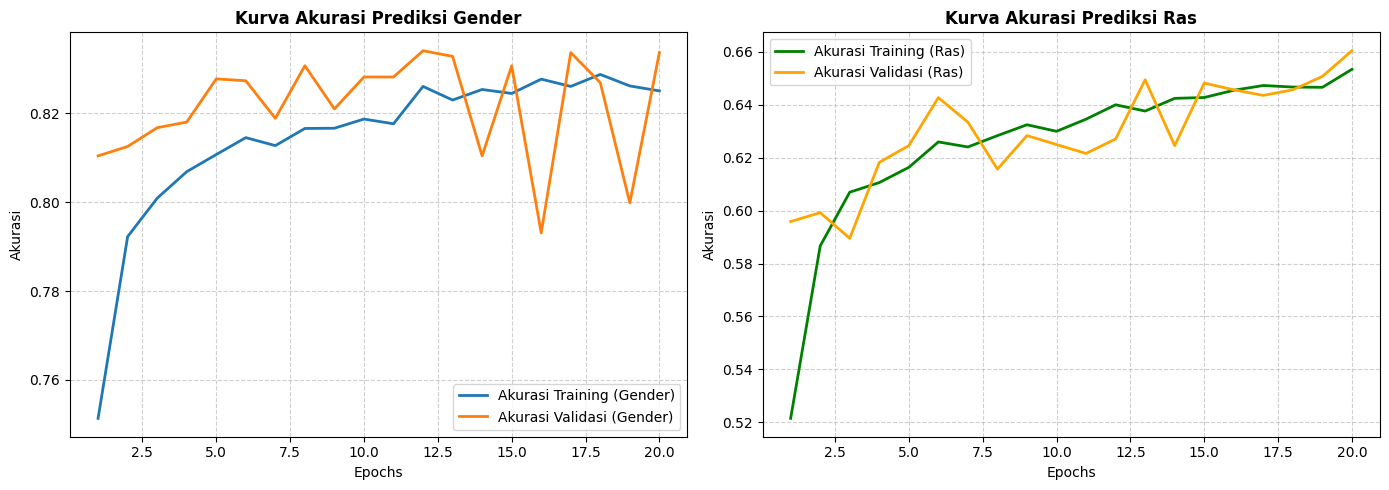

In [13]:
# Mengambil riwayat metrik dari proses training
acc_gender = history.history['gender_output_accuracy']
val_acc_gender = history.history['val_gender_output_accuracy']
acc_race = history.history['race_output_accuracy']
val_acc_race = history.history['val_race_output_accuracy']
epochs_range = range(1, len(acc_gender) + 1)

plt.figure(figsize=(14, 5))

# Grafik Akurasi Gender
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_gender, label='Akurasi Training (Gender)', linewidth=2)
plt.plot(epochs_range, val_acc_gender, label='Akurasi Validasi (Gender)', linewidth=2)
plt.title('Kurva Akurasi Prediksi Gender', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik Akurasi Ras
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc_race, label='Akurasi Training (Ras)', linewidth=2, color='green')
plt.plot(epochs_range, val_acc_race, label='Akurasi Validasi (Ras)', linewidth=2, color='orange')
plt.title('Kurva Akurasi Prediksi Ras', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Visualisasi Prediksi

1/1 [==============================] - 0s 101ms/step


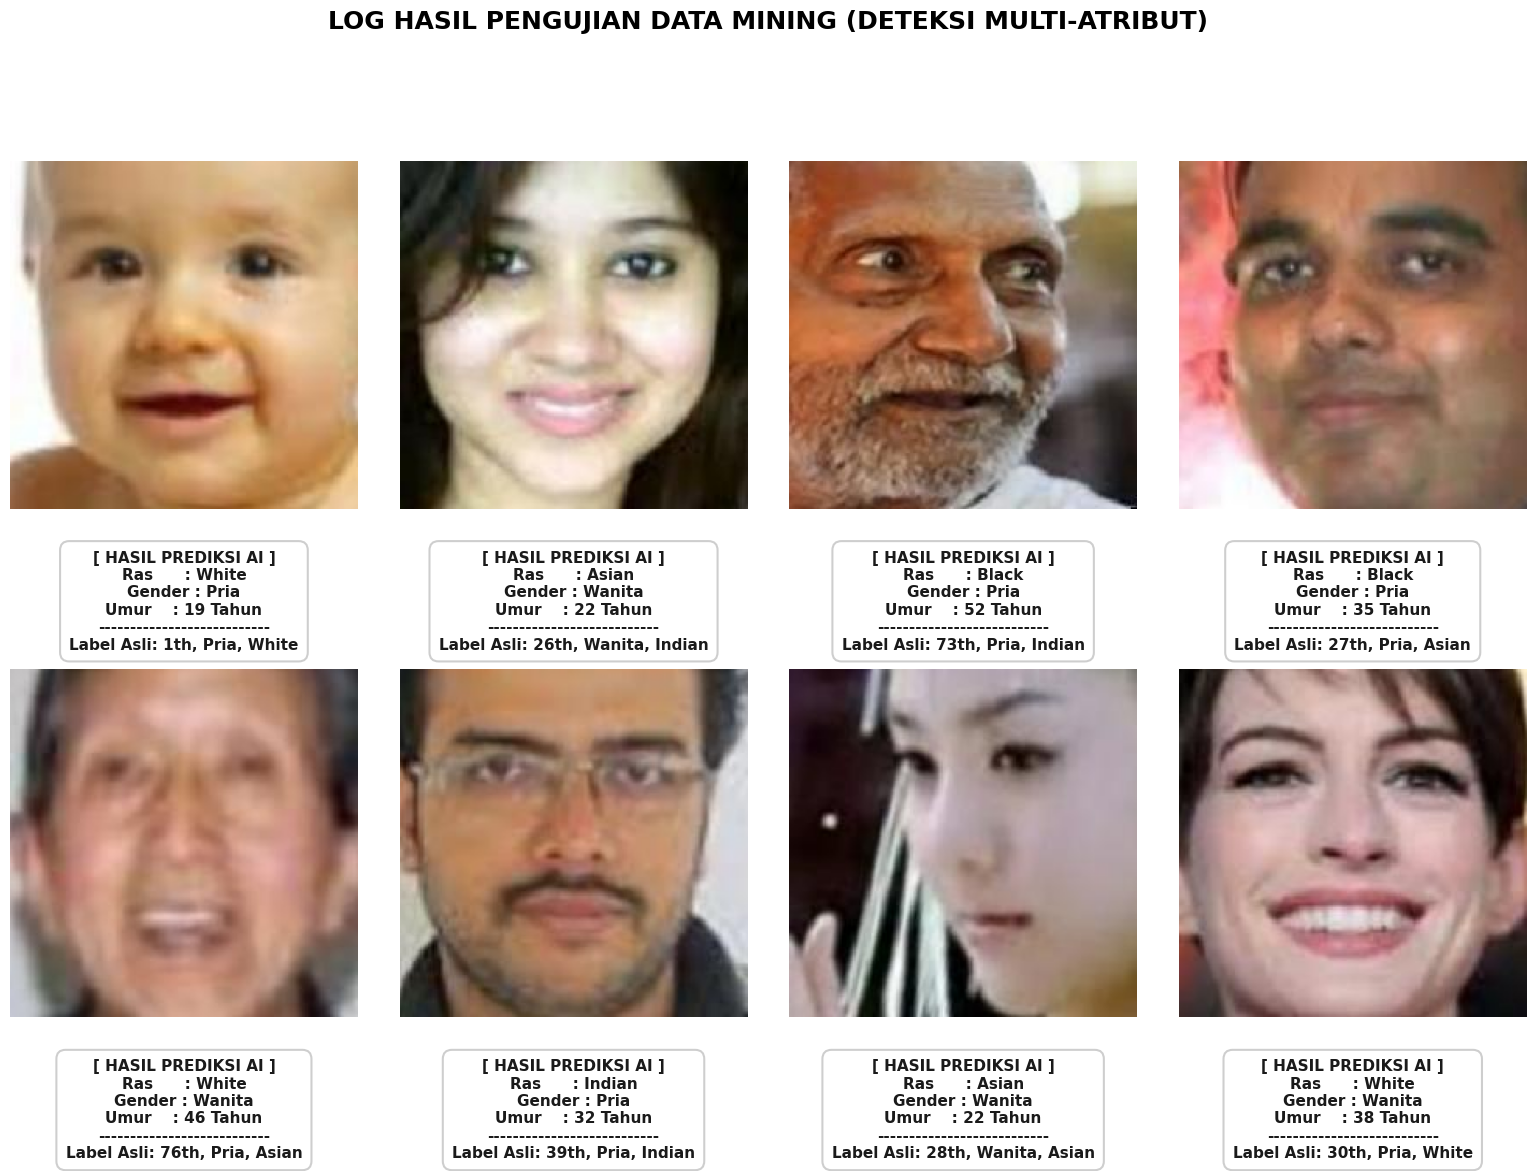

In [14]:
gender_dict = {0: 'Pria', 1: 'Wanita'}
race_dict = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}

val_images, val_labels = next(val_gen)
predictions = model.predict(val_images)

pred_ages = predictions[0].flatten()
pred_genders = np.round(predictions[1].flatten()).astype(int)
pred_races = np.argmax(predictions[2], axis=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
fig.suptitle("LOG HASIL PENGUJIAN DATA MINING (DETEKSI MULTI-ATRIBUT)", fontsize=18, fontweight='bold', y=0.98)

for i, ax in enumerate(axes.flat):
    if i < 8:
        ax.imshow(val_images[i])
        ax.axis('off') 
        
        real_age = val_labels['age_output'][i]
        real_gender = gender_dict[val_labels['gender_output'][i]]
        real_race = race_dict[val_labels['race_output'][i]]
        
        pred_age = int(pred_ages[i])
        pred_gender = gender_dict[pred_genders[i]]
        pred_race = race_dict[pred_races[i]]
        
        info_text = (
            f"[ HASIL PREDIKSI AI ]\n"
            f"Ras      : {pred_race}\n"
            f"Gender : {pred_gender}\n"
            f"Umur    : {pred_age} Tahun\n"
            f"---------------------------\n"
            f"Label Asli: {real_age}th, {real_gender}, {real_race}"
        )
        
        ax.text(
            0.5, -0.12, info_text, transform=ax.transAxes, 
            fontsize=11, color='#1A1A1A', fontweight='semibold',
            horizontalalignment='center', verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.95, edgecolor='#CCCCCC', boxstyle='round,pad=0.6', linewidth=1.5)
        )

plt.tight_layout(pad=3.0)
plt.show()

In [16]:
# Supress warning legacy format dari Keras
import warnings
warnings.filterwarnings('ignore')

folder_simpan = "models"

lokasi_file = os.path.join(folder_simpan, "model_deteksi_wajah.h5")
model.save(lokasi_file)
